# Multi-Rollout Analysis: Distance Travelled vs Noise Level

This notebook analyzes rollout data from `multi_prior_rollout.py` and computes distance travelled as a function of noise level.

In [36]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [37]:
# Load the H5 file
h5_path = Path("/home/mila/a/aidan.sirbu/scratch/track-mjx/multi_rollouts/260115_141734_544576/rollout_data.h5")
h5f = h5py.File(h5_path, "r")

In [38]:
# Explore the structure
def print_h5_structure(group, indent=0):
    for key in group.keys():
        item = group[key]
        if isinstance(item, h5py.Group):
            print(" " * indent + f"[Group] {key}")
            for attr_name, attr_val in item.attrs.items():
                print(" " * (indent + 2) + f"@{attr_name}: {attr_val}")
            print_h5_structure(item, indent + 2)
        else:
            print(" " * indent + f"[Dataset] {key}: {item.shape} {item.dtype}")

print_h5_structure(h5f)

[Group] deterministic
  @deterministic: True
  @fixed_logvar: N/A
  [Group] clip2_frame0
    @clip_idx: 2
    @mode: clip
    @num_rollouts: 1
    @start_frame: 0
    [Dataset] qpos: (1, 1000, 74) float32
    [Dataset] qvel: (1, 1000, 73) float32
    [Dataset] step_counts: (1,) int32
    [Dataset] terminated: (1,) bool
  [Group] clip3_frame0
    @clip_idx: 3
    @mode: clip
    @num_rollouts: 1
    @start_frame: 0
    [Dataset] qpos: (1, 1000, 74) float32
    [Dataset] qvel: (1, 1000, 73) float32
    [Dataset] step_counts: (1,) int32
    [Dataset] terminated: (1,) bool
  [Group] clip4_frame0
    @clip_idx: 4
    @mode: clip
    @num_rollouts: 1
    @start_frame: 0
    [Dataset] qpos: (1, 1000, 74) float32
    [Dataset] qvel: (1, 1000, 73) float32
    [Dataset] step_counts: (1,) int32
    [Dataset] terminated: (1,) bool
  [Group] neutral
    @mode: neutral
    @num_rollouts: 1
    [Dataset] qpos: (1, 1000, 74) float32
    [Dataset] qvel: (1, 1000, 73) float32
    [Dataset] step_counts: 

In [39]:
def calculate_distance_travelled(qpos: np.ndarray) -> np.ndarray:
    """
    Calculate total distance travelled for each rollout over all steps.
    
    Args:
        qpos: Shape (num_rollouts, max_steps, qpos_dim) - first 2 elements are x, y
    
    Returns:
        distances: Shape (num_rollouts,) - total distance travelled per rollout
    """
    # Extract x, y positions
    xy = qpos[:, :, :2]  # (num_rollouts, max_steps, 2)
    
    # Calculate differences between consecutive steps
    diffs = np.diff(xy, axis=1)  # (num_rollouts, max_steps-1, 2)
    
    # Calculate Euclidean distance at each step
    step_distances = np.linalg.norm(diffs, axis=2)  # (num_rollouts, max_steps-1)
    
    # Sum all distances (no masking based on termination)
    total_distances = np.sum(step_distances, axis=1)  # (num_rollouts,)
    
    return total_distances

In [40]:
def logvar_to_std(logvar: float) -> float:
    """Convert log-variance to standard deviation."""
    return np.exp(0.5 * logvar)

def parse_variance_config(var_name: str, var_group: h5py.Group) -> dict:
    """
    Parse variance configuration and return noise level info.
    
    Returns dict with:
        - name: original name
        - std: standard deviation (0 for deterministic)
        - sort_key: for ordering by noise level
    """
    deterministic = var_group.attrs.get("deterministic", False)
    fixed_logvar = var_group.attrs.get("fixed_logvar", None)
    
    if deterministic:
        return {"name": var_name, "std": 0.0, "sort_key": -np.inf, "label": "deterministic"}
    elif fixed_logvar == "predicted":
        # Predicted logvar - we'll put this at the end or handle separately
        return {"name": var_name, "std": None, "sort_key": np.inf, "label": "predicted"}
    else:
        std = logvar_to_std(float(fixed_logvar))
        return {"name": var_name, "std": std, "sort_key": std, "label": f"std={std:.3f}"}

In [41]:
# Collect all data
results = []

# Get all variance groups (skip metadata)
variance_groups = [k for k in h5f.keys() if k != "metadata"]

for var_name in variance_groups:
    var_group = h5f[var_name]
    var_info = parse_variance_config(var_name, var_group)
    
    # Get all starting poses
    for pose_name in var_group.keys():
        pose_group = var_group[pose_name]
        
        qpos = pose_group["qpos"][:]
        
        # Calculate distance over full rollout (ignoring termination)
        distances = calculate_distance_travelled(qpos)
        
        for i, dist in enumerate(distances):
            results.append({
                "variance_name": var_name,
                "std": var_info["std"],
                "sort_key": var_info["sort_key"],
                "label": var_info["label"],
                "pose": pose_name,
                "rollout_idx": i,
                "distance": dist,
            })

df = pd.DataFrame(results)
print(f"Total rollouts: {len(df)}")
df.head(10)

Total rollouts: 2804


,variance_name,std,sort_key,label,pose,rollout_idx,distance
0,deterministic,0.000000,-inf,deterministic,clip2_frame0,0,1.537660
1,deterministic,0.000000,-inf,deterministic,clip3_frame0,0,1.568549
2,deterministic,0.000000,-inf,deterministic,clip4_frame0,0,0.540615
3,deterministic,0.000000,-inf,deterministic,neutral,0,1.453390
4,logvar_-0.5,0.778801,0.778801,std=0.779,clip2_frame0,0,2.526090
5,logvar_-0.5,0.778801,0.778801,std=0.779,clip2_frame0,1,1.842189
6,logvar_-0.5,0.778801,0.778801,std=0.779,clip2_frame0,2,1.370485
7,logvar_-0.5,0.778801,0.778801,std=0.779,clip2_frame0,3,2.012690
8,logvar_-0.5,0.778801,0.778801,std=0.779,clip2_frame0,4,1.991397
9,logvar_-0.5,0.778801,0.778801,std=0.779,clip2_frame0,5,1.304279


In [42]:
# Summary statistics per variance level and pose
summary_by_pose = df.groupby(["variance_name", "label", "sort_key", "pose"]).agg(
    distance_mean=("distance", "mean"),
    distance_std=("distance", "std"),
    n_rollouts=("distance", "count"),
).reset_index()

# Fill NaN std with 0 (for single rollouts like deterministic)
summary_by_pose["distance_std"] = summary_by_pose["distance_std"].fillna(0)

# Sort by noise level
summary_by_pose = summary_by_pose.sort_values(["sort_key", "pose"])

print("Summary by Variance Level and Pose:")
print("=" * 80)
summary_by_pose

Summary by Variance Level and Pose:


,variance_name,label,sort_key,pose,distance_mean,distance_std,n_rollouts
0,deterministic,deterministic,-inf,clip2_frame0,1.537660,0.000000,1
1,deterministic,deterministic,-inf,clip3_frame0,1.568549,0.000000,1
2,deterministic,deterministic,-inf,clip4_frame0,0.540615,0.000000,1
3,deterministic,deterministic,-inf,neutral,1.453390,0.000000,1
20,logvar_-4.0,std=0.135,0.135335,clip2_frame0,1.404443,0.440219,100
21,logvar_-4.0,std=0.135,0.135335,clip3_frame0,1.426327,0.371329,100
22,logvar_-4.0,std=0.135,0.135335,clip4_frame0,1.614286,0.363386,100
23,logvar_-4.0,std=0.135,0.135335,neutral,1.602797,0.354353,100
16,logvar_-3.0,std=0.223,0.223130,clip2_frame0,1.203376,0.444529,100
17,logvar_-3.0,std=0.223,0.223130,clip3_frame0,1.444415,0.355135,100


In [43]:
# Summary statistics per variance level (averaged over all poses)
summary_overall = df.groupby(["variance_name", "label", "sort_key"]).agg(
    distance_mean=("distance", "mean"),
    distance_std=("distance", "std"),
    n_rollouts=("distance", "count"),
).reset_index()

summary_overall["distance_std"] = summary_overall["distance_std"].fillna(0)
summary_overall = summary_overall.sort_values("sort_key")

print("Summary by Variance Level (averaged over all poses):")
print("=" * 80)
summary_overall

Summary by Variance Level (averaged over all poses):


,variance_name,label,sort_key,distance_mean,distance_std,n_rollouts
0,deterministic,deterministic,-inf,1.275054,0.492038,4
5,logvar_-4.0,std=0.135,0.135335,1.511963,0.394516,400
4,logvar_-3.0,std=0.223,0.223130,1.331083,0.452373,400
3,logvar_-2.0,std=0.368,0.367879,1.600027,0.446787,400
2,logvar_-1.0,std=0.607,0.606531,1.890019,0.369414,400
1,logvar_-0.5,std=0.779,0.778801,2.061019,0.393428,400
6,logvar_0.0,std=1.000,1.000000,2.271627,0.322471,400
7,predicted_logvar,predicted,inf,1.824149,0.313277,400


In [44]:
# Pivot table for easy viewing: rows = variance, columns = pose
pivot_mean = df.pivot_table(
    index=["sort_key", "label"],
    columns="pose",
    values="distance",
    aggfunc="mean"
).reset_index().sort_values("sort_key")

pivot_std = df.pivot_table(
    index=["sort_key", "label"],
    columns="pose",
    values="distance",
    aggfunc="std"
).reset_index().sort_values("sort_key").fillna(0)

print("Distance Travelled (Mean):")
print(pivot_mean.to_string(index=False))
print("\nDistance Travelled (Std):")
print(pivot_std.to_string(index=False))

Distance Travelled (Mean):
 sort_key         label  clip2_frame0  clip3_frame0  clip4_frame0  neutral
     -inf deterministic      1.537660      1.568549      0.540615 1.453390
 0.135335     std=0.135      1.404443      1.426327      1.614286 1.602797
 0.223130     std=0.223      1.203376      1.444415      1.044646 1.631894
 0.367879     std=0.368      1.449853      1.605921      1.448037 1.896297
 0.606531     std=0.607      1.952031      1.891138      1.653673 2.063234
 0.778801     std=0.779      2.048458      2.065077      1.896913 2.233627
 1.000000     std=1.000      2.308666      2.253332      2.181708 2.342803
      inf     predicted      1.826823      1.840391      1.701573 1.927807

Distance Travelled (Std):
 sort_key     label  clip2_frame0  clip3_frame0  clip4_frame0  neutral
 0.135335 std=0.135      0.440219      0.371329      0.363386 0.354353
 0.223130 std=0.223      0.444529      0.355135      0.387214 0.383901
 0.367879 std=0.368      0.454020      0.348056      0.409

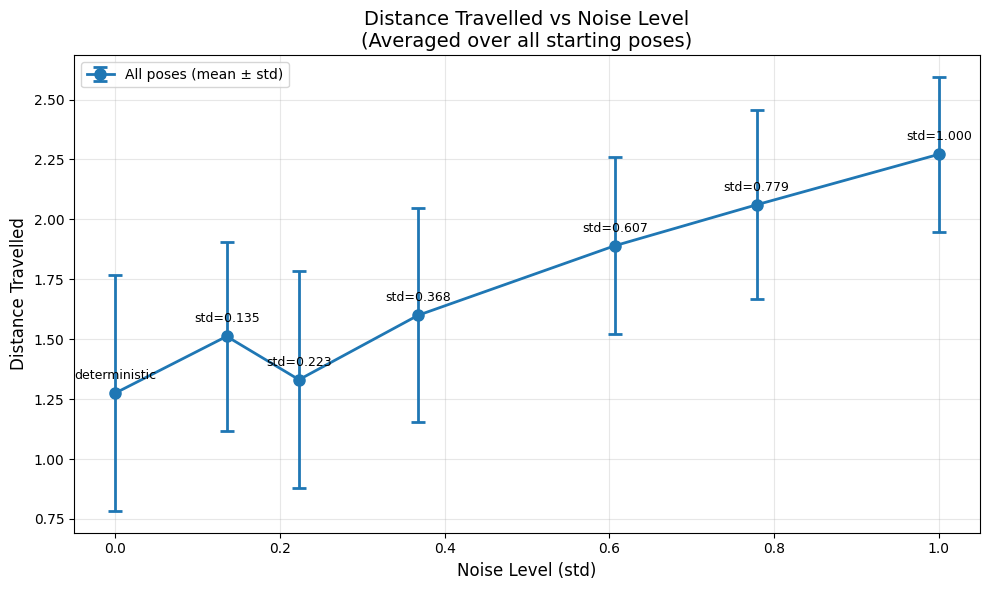

In [45]:
# Plot: Distance vs Noise Level (averaged over all poses)
# Exclude 'predicted' variance for the main plot (since it doesn't have a fixed std)
plot_data = summary_overall[summary_overall["sort_key"] != np.inf].copy()

fig, ax = plt.subplots(figsize=(10, 6))

# For deterministic (std=0), use a small value for log scale or plot at 0
x_values = plot_data["sort_key"].values.copy()
x_values[x_values == -np.inf] = 0  # deterministic -> 0

ax.errorbar(
    x_values,
    plot_data["distance_mean"],
    yerr=plot_data["distance_std"],
    marker="o",
    capsize=5,
    capthick=2,
    linewidth=2,
    markersize=8,
    label="All poses (mean ± std)"
)

# Add labels for each point
for i, row in plot_data.iterrows():
    x = 0 if row["sort_key"] == -np.inf else row["sort_key"]
    ax.annotate(
        row["label"],
        (x, row["distance_mean"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9
    )

ax.set_xlabel("Noise Level (std)", fontsize=12)
ax.set_ylabel("Distance Travelled", fontsize=12)
ax.set_title("Distance Travelled vs Noise Level\n(Averaged over all starting poses)", fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

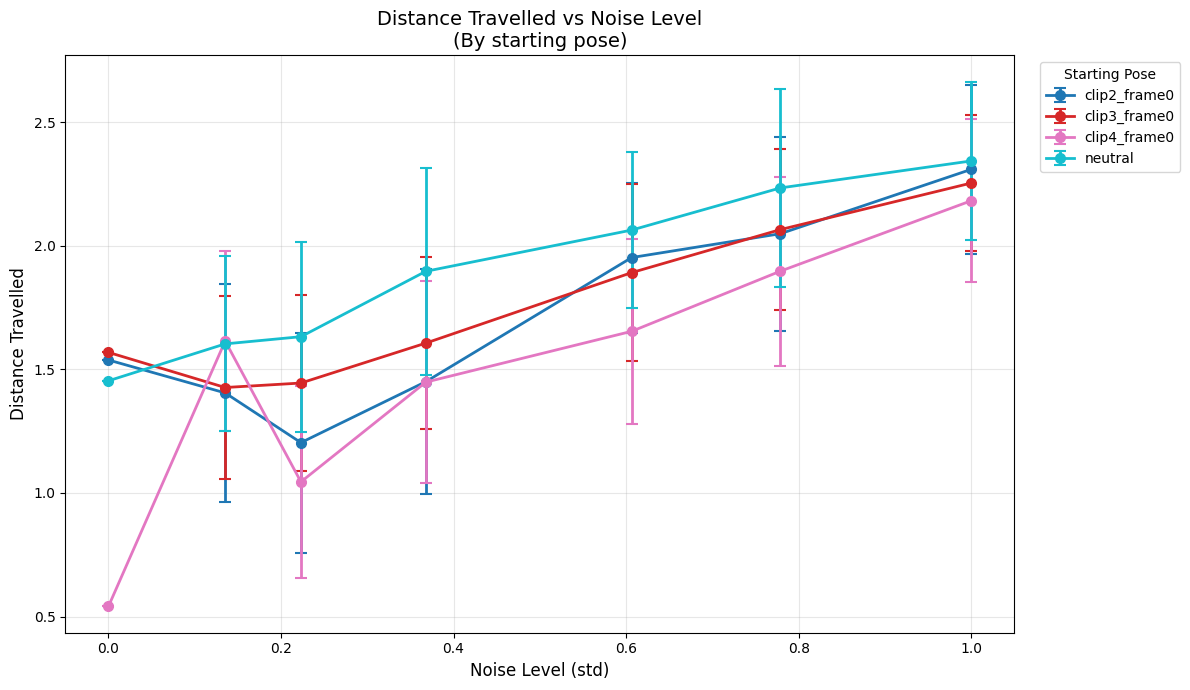

In [46]:
# Plot: Distance vs Noise Level (separate line for each starting pose)
plot_data_by_pose = summary_by_pose[summary_by_pose["sort_key"] != np.inf].copy()

fig, ax = plt.subplots(figsize=(12, 7))

poses = plot_data_by_pose["pose"].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(poses)))

for pose, color in zip(poses, colors):
    pose_data = plot_data_by_pose[plot_data_by_pose["pose"] == pose].sort_values("sort_key")
    
    x_values = pose_data["sort_key"].values.copy()
    x_values[x_values == -np.inf] = 0
    
    ax.errorbar(
        x_values,
        pose_data["distance_mean"],
        yerr=pose_data["distance_std"],
        marker="o",
        capsize=4,
        capthick=1.5,
        linewidth=2,
        markersize=7,
        color=color,
        label=pose
    )

ax.set_xlabel("Noise Level (std)", fontsize=12)
ax.set_ylabel("Distance Travelled", fontsize=12)
ax.set_title("Distance Travelled vs Noise Level\n(By starting pose)", fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(title="Starting Pose", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [47]:
# Close the H5 file
h5f.close()

# Rearing Detection Analysis

This section analyzes z-values to detect rearing events (when the rodent stands on its hind legs).

In [48]:
# Reopen the H5 file for rearing analysis
h5f = h5py.File(h5_path, "r")

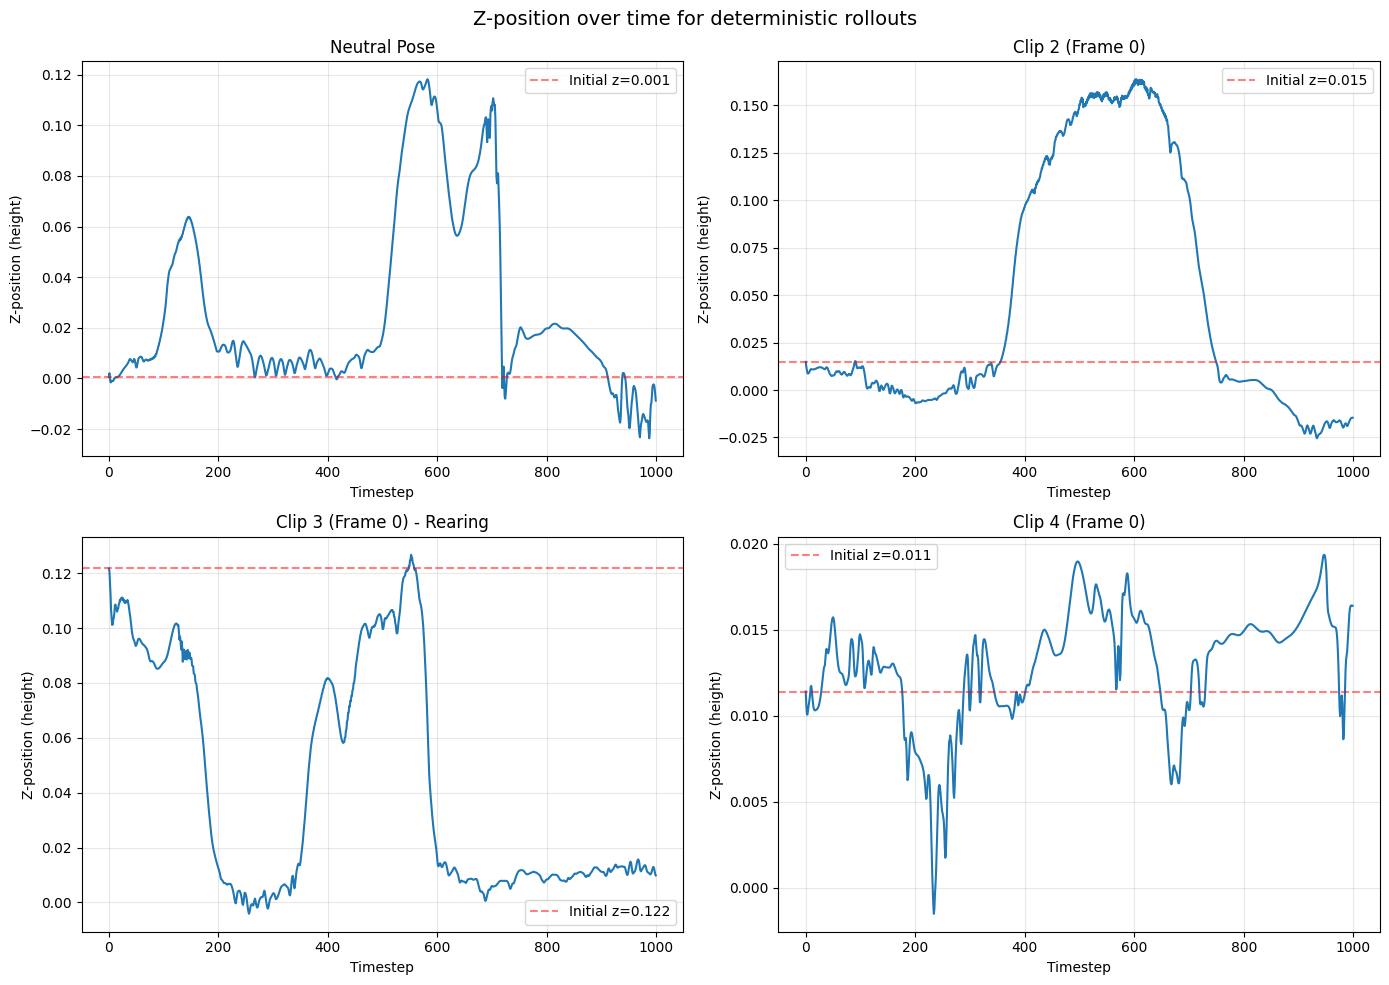


Initial z-values by starting pose (deterministic):
  neutral: z=0.0007
  clip2_frame0: z=0.0148
  clip3_frame0: z=0.1218
  clip4_frame0: z=0.0114


In [49]:
# Plot z-values over time for different clips to find rearing threshold
# clip3 starts in a rearing pose, so it should have high initial z-values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot deterministic rollouts for each starting pose
det_group = h5f["deterministic"]

poses = ["neutral", "clip2_frame0", "clip3_frame0", "clip4_frame0"]
titles = ["Neutral Pose", "Clip 2 (Frame 0)", "Clip 3 (Frame 0) - Rearing", "Clip 4 (Frame 0)"]

for ax, pose, title in zip(axes.flat, poses, titles):
    qpos = det_group[pose]["qpos"][0]  # Shape: (1000, 74), take first rollout
    z_values = qpos[:, 2]  # z-position is index 2
    
    ax.plot(z_values, linewidth=1.5)
    ax.axhline(y=z_values[0], color='r', linestyle='--', alpha=0.5, label=f'Initial z={z_values[0]:.3f}')
    ax.set_xlabel("Timestep")
    ax.set_ylabel("Z-position (height)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Z-position over time for deterministic rollouts", fontsize=14)
plt.tight_layout()
plt.show()

# Print initial z-values for comparison
print("\nInitial z-values by starting pose (deterministic):")
for pose in poses:
    qpos = det_group[pose]["qpos"][0]
    print(f"  {pose}: z={qpos[0, 2]:.4f}")

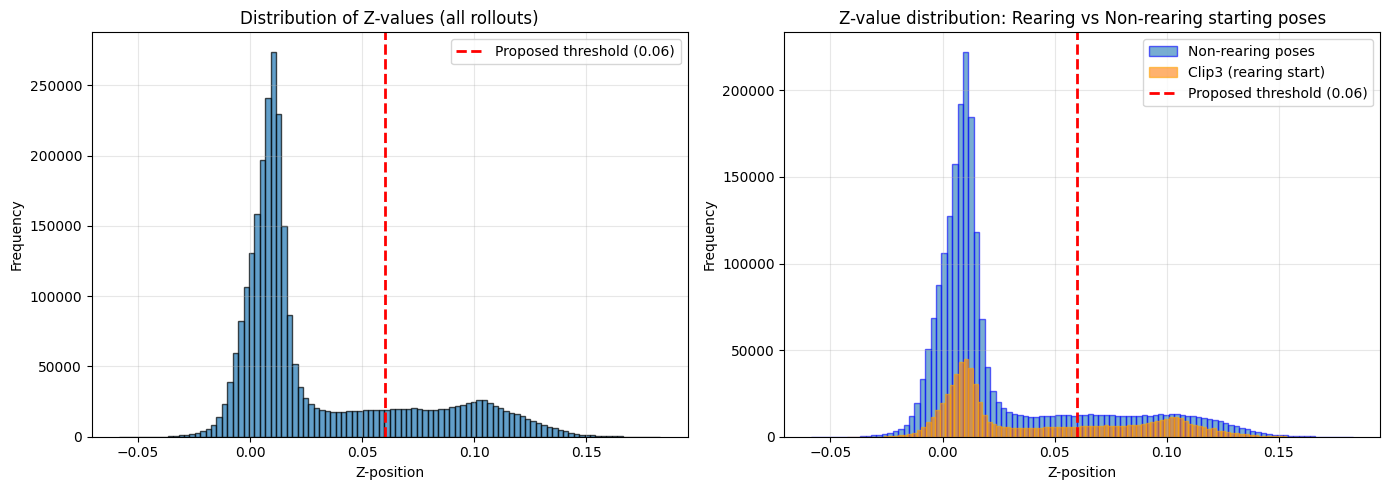


Z-value statistics:
  All rollouts:      min=-0.0585, max=0.1830, mean=0.0297
  Non-rearing poses: min=-0.0585, max=0.1830, mean=0.0256
  Clip3 (rearing):   min=-0.0427, max=0.1656, mean=0.0420


In [50]:
# Histogram of z-values across all rollouts to identify threshold
all_z_values = []
rearing_z_values = []  # z-values from clip3 (rearing pose)
non_rearing_z_values = []  # z-values from other poses

for var_name in h5f.keys():
    if var_name == "metadata":
        continue
    var_group = h5f[var_name]
    for pose_name in var_group.keys():
        qpos = var_group[pose_name]["qpos"][:]  # Shape: (num_rollouts, steps, 74)
        z = qpos[:, :, 2].flatten()
        all_z_values.extend(z)
        
        if "clip3" in pose_name:
            rearing_z_values.extend(z)
        else:
            non_rearing_z_values.extend(z)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall histogram
ax = axes[0]
ax.hist(all_z_values, bins=100, alpha=0.7, edgecolor='black')
ax.set_xlabel("Z-position")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Z-values (all rollouts)")
ax.axvline(x=0.06, color='r', linestyle='--', linewidth=2, label='Proposed threshold (0.06)')
ax.legend()
ax.grid(True, alpha=0.3)

# Compare rearing vs non-rearing
ax = axes[1]
ax.hist(non_rearing_z_values, bins=100, alpha=0.6, label='Non-rearing poses', edgecolor='blue')
ax.hist(rearing_z_values, bins=100, alpha=0.6, label='Clip3 (rearing start)', edgecolor='orange')
ax.set_xlabel("Z-position")
ax.set_ylabel("Frequency")
ax.set_title("Z-value distribution: Rearing vs Non-rearing starting poses")
ax.axvline(x=0.06, color='r', linestyle='--', linewidth=2, label='Proposed threshold (0.06)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nZ-value statistics:")
print(f"  All rollouts:      min={np.min(all_z_values):.4f}, max={np.max(all_z_values):.4f}, mean={np.mean(all_z_values):.4f}")
print(f"  Non-rearing poses: min={np.min(non_rearing_z_values):.4f}, max={np.max(non_rearing_z_values):.4f}, mean={np.mean(non_rearing_z_values):.4f}")
print(f"  Clip3 (rearing):   min={np.min(rearing_z_values):.4f}, max={np.max(rearing_z_values):.4f}, mean={np.mean(rearing_z_values):.4f}")

In [51]:
# Define rearing threshold and detection function
REARING_THRESHOLD = 0.06

def detect_rearing_events(z_values, threshold=REARING_THRESHOLD):
    """
    Count rearing events by detecting threshold crossings.
    A rearing event starts when z crosses above threshold, ends when it crosses below.
    """
    above_threshold = (z_values > threshold).astype(int)
    diff = np.diff(above_threshold)
    rising_edges = np.where(diff == 1)[0] + 1
    falling_edges = np.where(diff == -1)[0] + 1
    
    starts_above = above_threshold[0] == 1
    ends_above = above_threshold[-1] == 1
    
    if starts_above and ends_above:
        num_events = len(rising_edges) + 1
    elif starts_above:
        num_events = len(rising_edges) + 1
    elif ends_above:
        num_events = len(rising_edges)
    else:
        num_events = len(rising_edges)
    
    return {
        "num_events": num_events,
        "rising_edges": rising_edges,
        "falling_edges": falling_edges,
        "time_above": np.sum(above_threshold),
        "starts_above": starts_above,
        "ends_above": ends_above,
    }

# Test the function
test_z = det_group["clip3_frame0"]["qpos"][0, :, 2]
result = detect_rearing_events(test_z)
print(f"Test on clip3_frame0 deterministic rollout:")
print(f"  Rearing events: {result['num_events']}")
print(f"  Time above threshold: {result['time_above']} timesteps ({100*result['time_above']/len(test_z):.1f}%)")
print(f"  Starts above: {result['starts_above']}, Ends above: {result['ends_above']}")

Test on clip3_frame0 deterministic rollout:
  Rearing events: 3
  Time above threshold: 377 timesteps (37.7%)
  Starts above: True, Ends above: False


In [52]:
# Calculate rearing statistics for all rollouts
rearing_results = []

for var_name in h5f.keys():
    if var_name == "metadata":
        continue
    var_group = h5f[var_name]
    var_info = parse_variance_config(var_name, var_group)
    
    for pose_name in var_group.keys():
        pose_group = var_group[pose_name]
        qpos = pose_group["qpos"][:]
        num_rollouts = qpos.shape[0]
        
        for rollout_idx in range(num_rollouts):
            z_values = qpos[rollout_idx, :, 2]
            detection = detect_rearing_events(z_values, REARING_THRESHOLD)
            
            rearing_results.append({
                "variance_name": var_name,
                "std": var_info["std"],
                "sort_key": var_info["sort_key"],
                "label": var_info["label"],
                "pose": pose_name,
                "rollout_idx": rollout_idx,
                "rearing_events": detection["num_events"],
                "time_above": detection["time_above"],
                "pct_time_rearing": 100 * detection["time_above"] / len(z_values),
                "starts_rearing": detection["starts_above"],
            })

rearing_df = pd.DataFrame(rearing_results)
print(f"Analyzed {len(rearing_df)} rollouts")
rearing_df.head(10)

Analyzed 2804 rollouts


,variance_name,std,sort_key,label,pose,rollout_idx,rearing_events,time_above,pct_time_rearing,starts_rearing
0,deterministic,0.000000,-inf,deterministic,clip2_frame0,0,1,342,34.2,False
1,deterministic,0.000000,-inf,deterministic,clip3_frame0,0,3,377,37.7,True
2,deterministic,0.000000,-inf,deterministic,clip4_frame0,0,0,0,0.0,False
3,deterministic,0.000000,-inf,deterministic,neutral,0,3,195,19.5,False
4,logvar_-0.5,0.778801,0.778801,std=0.779,clip2_frame0,0,2,185,18.5,False
5,logvar_-0.5,0.778801,0.778801,std=0.779,clip2_frame0,1,1,32,3.2,False
6,logvar_-0.5,0.778801,0.778801,std=0.779,clip2_frame0,2,0,0,0.0,False
7,logvar_-0.5,0.778801,0.778801,std=0.779,clip2_frame0,3,3,420,42.0,False
8,logvar_-0.5,0.778801,0.778801,std=0.779,clip2_frame0,4,3,198,19.8,False
9,logvar_-0.5,0.778801,0.778801,std=0.779,clip2_frame0,5,0,0,0.0,False


In [53]:
# Summary statistics: rearing events by variance level and starting pose
rearing_summary = rearing_df.groupby(["variance_name", "label", "sort_key", "pose"]).agg(
    mean_events=("rearing_events", "mean"),
    std_events=("rearing_events", "std"),
    mean_pct_time=("pct_time_rearing", "mean"),
    n_rollouts=("rearing_events", "count"),
).reset_index()

rearing_summary["std_events"] = rearing_summary["std_events"].fillna(0)
rearing_summary = rearing_summary.sort_values(["sort_key", "pose"])

print("Rearing Events Summary (by variance level and pose):")
print("=" * 100)
rearing_summary

Rearing Events Summary (by variance level and pose):


,variance_name,label,sort_key,pose,mean_events,std_events,mean_pct_time,n_rollouts
0,deterministic,deterministic,-inf,clip2_frame0,1.00,0.000000,34.200,1
1,deterministic,deterministic,-inf,clip3_frame0,3.00,0.000000,37.700,1
2,deterministic,deterministic,-inf,clip4_frame0,0.00,0.000000,0.000,1
3,deterministic,deterministic,-inf,neutral,3.00,0.000000,19.500,1
20,logvar_-4.0,std=0.135,0.135335,clip2_frame0,1.23,0.983243,17.448,100
21,logvar_-4.0,std=0.135,0.135335,clip3_frame0,2.68,1.246247,36.243,100
22,logvar_-4.0,std=0.135,0.135335,clip4_frame0,1.29,0.977474,15.810,100
23,logvar_-4.0,std=0.135,0.135335,neutral,1.73,1.354789,23.849,100
16,logvar_-3.0,std=0.223,0.223130,clip2_frame0,0.89,1.144993,11.074,100
17,logvar_-3.0,std=0.223,0.223130,clip3_frame0,2.91,1.484567,45.033,100


Mean Rearing Events (pivot table):
 sort_key         label  clip2_frame0  clip3_frame0  clip4_frame0  neutral
     -inf deterministic          1.00          3.00          0.00     3.00
 0.135335     std=0.135          1.23          2.68          1.29     1.73
 0.223130     std=0.223          0.89          2.91          0.64     2.22
 0.367879     std=0.368          1.26          2.99          1.17     2.71
 0.606531     std=0.607          1.96          3.51          1.63     3.04
 0.778801     std=0.779          2.01          3.68          1.53     2.74
 1.000000     std=1.000          1.94          3.41          1.93     2.65
      inf     predicted          1.84          3.34          1.52     2.79


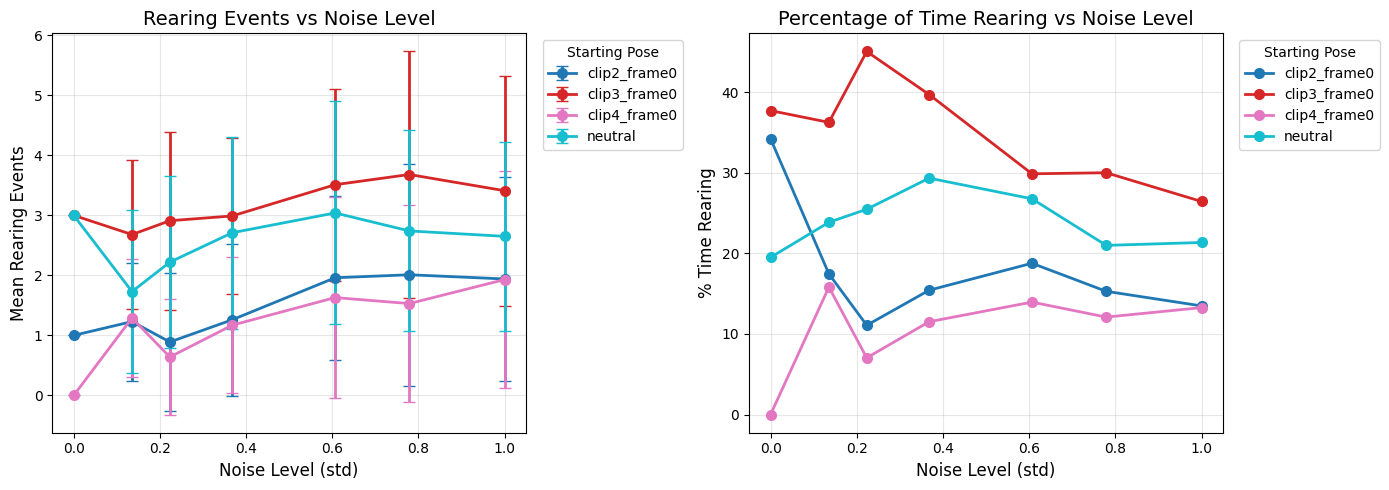

In [54]:
# Pivot table and plots for rearing events
pivot_rearing = rearing_df.pivot_table(
    index=["sort_key", "label"],
    columns="pose",
    values="rearing_events",
    aggfunc="mean"
).reset_index().sort_values("sort_key")

print("Mean Rearing Events (pivot table):")
print(pivot_rearing.to_string(index=False))

# Plot: Rearing events vs Noise Level by starting pose
plot_rearing = rearing_summary[rearing_summary["sort_key"] != np.inf].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

poses = plot_rearing["pose"].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(poses)))

# Plot rearing events
ax = axes[0]
for pose, color in zip(poses, colors):
    pose_data = plot_rearing[plot_rearing["pose"] == pose].sort_values("sort_key")
    x_values = pose_data["sort_key"].values.copy()
    x_values[x_values == -np.inf] = 0
    ax.errorbar(x_values, pose_data["mean_events"], yerr=pose_data["std_events"],
                marker="o", capsize=4, linewidth=2, markersize=7, color=color, label=pose)

ax.set_xlabel("Noise Level (std)", fontsize=12)
ax.set_ylabel("Mean Rearing Events", fontsize=12)
ax.set_title("Rearing Events vs Noise Level", fontsize=14)
ax.legend(title="Starting Pose", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)

# Plot percentage of time rearing
ax = axes[1]
for pose, color in zip(poses, colors):
    pose_data = plot_rearing[plot_rearing["pose"] == pose].sort_values("sort_key")
    x_values = pose_data["sort_key"].values.copy()
    x_values[x_values == -np.inf] = 0
    ax.plot(x_values, pose_data["mean_pct_time"], marker="o", linewidth=2, 
            markersize=7, color=color, label=pose)

ax.set_xlabel("Noise Level (std)", fontsize=12)
ax.set_ylabel("% Time Rearing", fontsize=12)
ax.set_title("Percentage of Time Rearing vs Noise Level", fontsize=14)
ax.legend(title="Starting Pose", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

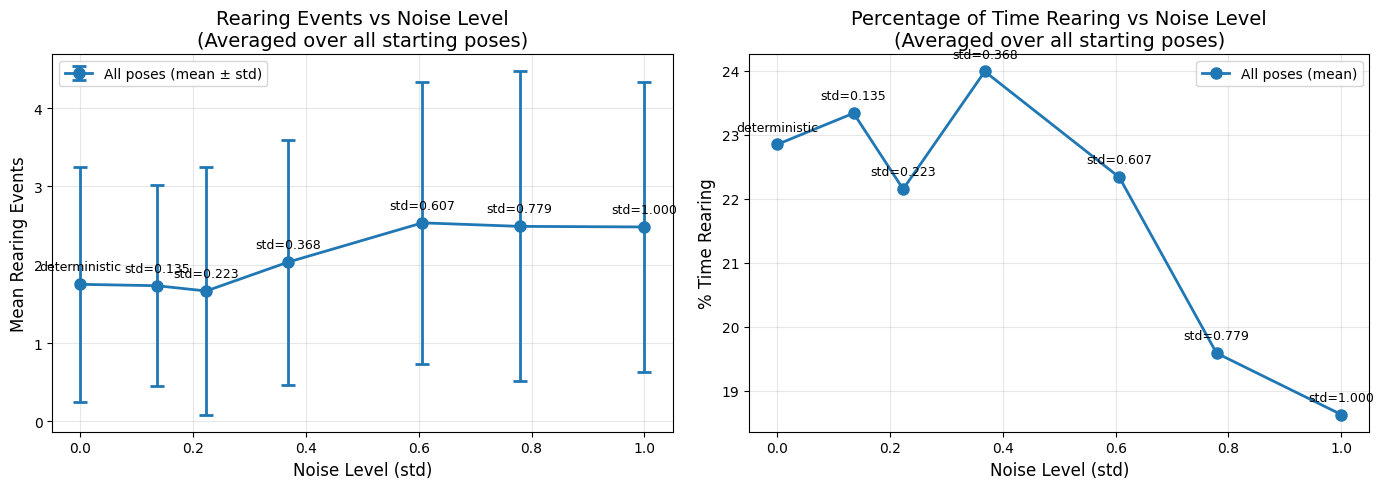

In [57]:
# Plot: Rearing Events vs Noise Level (averaged over all starting poses)
rearing_overall = rearing_df.groupby(["variance_name", "label", "sort_key"]).agg(
    mean_events=("rearing_events", "mean"),
    std_events=("rearing_events", "std"),
    mean_pct_time=("pct_time_rearing", "mean"),
    n_rollouts=("rearing_events", "count"),
).reset_index()

rearing_overall["std_events"] = rearing_overall["std_events"].fillna(0)
rearing_overall = rearing_overall.sort_values("sort_key")

# Exclude predicted logvar for cleaner plot
plot_overall = rearing_overall[rearing_overall["sort_key"] != np.inf].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rearing events
ax = axes[0]
x_values = plot_overall["sort_key"].values.copy()
x_values[x_values == -np.inf] = 0

ax.errorbar(
    x_values,
    plot_overall["mean_events"],
    yerr=plot_overall["std_events"],
    marker="o",
    capsize=5,
    capthick=2,
    linewidth=2,
    markersize=8,
    label="All poses (mean ± std)"
)

for i, row in plot_overall.iterrows():
    x = 0 if row["sort_key"] == -np.inf else row["sort_key"]
    ax.annotate(row["label"], (x, row["mean_events"]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)

ax.set_xlabel("Noise Level (std)", fontsize=12)
ax.set_ylabel("Mean Rearing Events", fontsize=12)
ax.set_title("Rearing Events vs Noise Level\n(Averaged over all starting poses)", fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

# Percentage of time rearing
ax = axes[1]
ax.errorbar(
    x_values,
    plot_overall["mean_pct_time"],
    marker="o",
    capsize=5,
    capthick=2,
    linewidth=2,
    markersize=8,
    label="All poses (mean)"
)

for i, row in plot_overall.iterrows():
    x = 0 if row["sort_key"] == -np.inf else row["sort_key"]
    ax.annotate(row["label"], (x, row["mean_pct_time"]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)

ax.set_xlabel("Noise Level (std)", fontsize=12)
ax.set_ylabel("% Time Rearing", fontsize=12)
ax.set_title("Percentage of Time Rearing vs Noise Level\n(Averaged over all starting poses)", fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Close the H5 file
h5f.close()
print("Analysis complete!")